In [ ]:
# inport the important library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [ ]:
# make the dataset which is inbuild in the sklearn
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,      # 100 observations
    n_features=3,       # 3 total features
    n_redundant=1,
    n_classes=2,        # binary target
    random_state=99
)

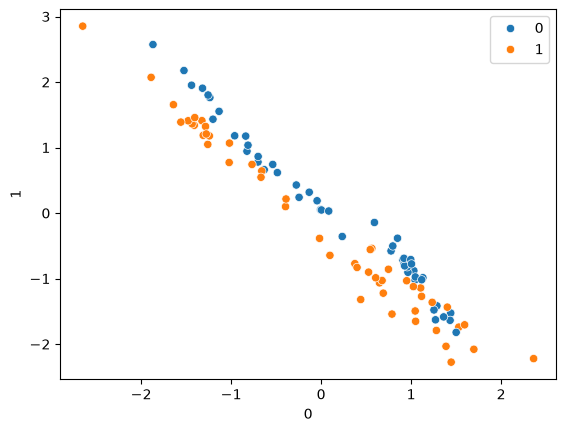

In [ ]:
# to see the visuals of the data using scattter plot 

import pandas as pd 

X_df = pd.DataFrame(X)

sns.scatterplot(
    x=X_df[0],
    y=X_df[1],
    hue=y
)

plt.show()


In [ ]:
# split the data into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [6]:
# import the model to train with data 
from sklearn.neighbors import KNeighborsClassifier

In [7]:
classifier = KNeighborsClassifier(n_neighbors=5,algorithm='auto')  
classifier.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [8]:
y_pred = classifier.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [10]:
print(confusion_matrix(y_pred,y_test))
print(classification_report(y_pred,y_test))
print(accuracy_score (y_pred,y_test))

[[15  2]
 [ 0 13]]
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        17
           1       0.87      1.00      0.93        13

    accuracy                           0.93        30
   macro avg       0.93      0.94      0.93        30
weighted avg       0.94      0.93      0.93        30

0.9333333333333333


In [ ]:
## perform gridsearchCV
#see i need to perform hyperparameter tunning in the form of key value
# pair give the different different valu of k let it decide which one is 
# the best k valu for it 



In [11]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid in a key-value pair format
# We'll test different values for 'n_neighbors' (k) 
param_grid = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'] # Optional: you can test other params too
}


In [12]:
# 2. Initialize the model and GridSearchCV
knn = KNeighborsClassifier()
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='accuracy',  # We'll evaluate the models using accuracy
    cv=5                 # 5-fold cross-validation
)

In [13]:
# 3. Fit the grid search to your training data
grid_search.fit(X_train, y_train)

# 4. Let it tell you what the best key-value parameters were
print("Best Parameters (Best K):", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)


Best Parameters (Best K): {'algorithm': 'auto', 'n_neighbors': 4}
Best Cross-Validation Accuracy: 0.8857142857142858


In [14]:
# 5. Evaluate the best model on the test data
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)

from sklearn.metrics import accuracy_score
print("Test Accuracy with Best Model:", accuracy_score(y_test, y_pred_best))

Test Accuracy with Best Model: 0.9333333333333333
